# Rap Corpus - Exploratory Analysis
## Descriptive Statistics and Initial Exploration

This notebook provides an initial analysis of the rap corpus with descriptive statistics, visualizations and insights into the composition of the corpus.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import os
import re
from pathlib import Path
from wordcloud import WordCloud

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Setup - Create Output Directories

In [3]:
# Create output directories if they don't exist
images_dir = Path('images')
export_dir = Path('export')

images_dir.mkdir(exist_ok=True)
export_dir.mkdir(exist_ok=True)

print(f"✓ 'images' folder created: {images_dir.resolve()}")
print(f"✓ 'export' folder created: {export_dir.resolve()}")

✓ 'images' folder created: /home/cbenavent/test/Rap/images
✓ 'export' folder created: /home/cbenavent/test/Rap/export


## 2. Load the Corpus File

In [4]:
# Corpus file path
corpus_path = Path('.') / 'corpus.csv'

# Load corpus with error handling
try:
    df = pd.read_csv(corpus_path, encoding='utf-8', on_bad_lines='skip')
    print(f"✓ Corpus loaded successfully from: {corpus_path}")
except UnicodeDecodeError:
    df = pd.read_csv(corpus_path, encoding='latin-1', on_bad_lines='skip')
    print(f"✓ Corpus loaded with latin-1 encoding from: {corpus_path}")

print(f"\nCorpus shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst rows of corpus:")
df.head()

✓ Corpus loaded successfully from: corpus.csv

Corpus shape: (85023, 10)

Columns: ['Unnamed: 0', 'artist', 'title', 'year', 'album', 'lyrics', 'n_words', 'pageviews', 'contributors', 'url']

First rows of corpus:


,Unnamed: 0,artist,title,year,album,lyrics,n_words,pageviews,contributors,url
0,1,Dry,94310,2012.0,Tôt ou tard,"[Paroles de ""94310"" ft. Madj, Larso & Stokas]\...",748,0,8,https://genius.com/Dry-94310-lyrics
1,2,Mafia K’1 Fry,Au bon vieux temps,2007.0,Jusqu’à la mort,"\nEt je les entends tous les Zoulous, ils parl...",958,7514,8,https://genius.com/Mafia-k1-fry-au-bon-vieux-t...
2,3,DJ Hamida,Attrape-Moi Si Tu Peux,NaN,Mix Party 2015,[Refrain : Charly Bell]\nOui je sais qu’t’as e...,367,0,4,https://genius.com/Dj-hamida-attrape-moi-si-tu...
3,4,Kery James,94 c’est le Barça Remix,NaN,NaN,"\nC'est pour les rudeboys, c'est pour les cail...",535,0,7,https://genius.com/Kery-james-94-cest-le-barca...
4,5,Dry,14 ans déjà,2013.0,Maintenant ou jamais,"[Paroles de ""14 ans déjà""]\n\n\nTu sais, j'cro...",653,5037,8,https://genius.com/Dry-14-ans-deja-lyrics


## 3. Basic Corpus Information

In [4]:
print("=" * 60)
print("BASIC CORPUS INFORMATION")
print("=" * 60)

# Global metadata
print(f"\nTotal number of documents: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory size: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Statistics by column
print("\n" + "=" * 60)
print("STATISTICS BY COLUMN")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(df.describe(include='all').T)

INFORMATIONS BASIQUES DU CORPUS

Nombre total de documents : 85,023
Nombre de colonnes : 10
Taille mémoire : 224.65 MB

STATISTIQUES PAR COLONNE
<class 'pandas.DataFrame'>
RangeIndex: 85023 entries, 0 to 85022
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    85023 non-null  int64  
 1   artist        85023 non-null  str    
 2   title         85023 non-null  str    
 3   year          75403 non-null  float64
 4   album         69880 non-null  str    
 5   lyrics        84852 non-null  str    
 6   n_words       85023 non-null  int64  
 7   pageviews     85023 non-null  int64  
 8   contributors  85023 non-null  int64  
 9   url           85023 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 224.7 MB

APERÇU DES DONNÉES
                count unique                                  top freq  \
Unnamed: 0    85023.0    NaN                                  NaN  NaN   
artist       

## 4. Text Length Statistics

In [5]:
# Define the text column to analyze
text_col = 'lyrics'

# Verify the column exists
if text_col not in df.columns:
    print(f"Error: Column '{text_col}' not found in dataset")
    print(f"Available columns: {df.columns.tolist()}")
else:
    print(f"✓ Analysis will focus on the '{text_col}' column")

✓ Analysis will focus on the 'lyrics' column



TEXT LENGTH STATISTICS - LYRICS ANALYSIS

Characters per document:
  Minimum: 0 characters
  Maximum: 108,422 characters
  Mean: 2,538 characters
  Median: 2,409 characters
  Std Dev: 1,486

Words per document:
  Minimum: 0 words
  Maximum: 11,302 words
  Mean: 456 words
  Median: 433 words
  Std Dev: 257

✓ Figure saved: images/01_text_length.png


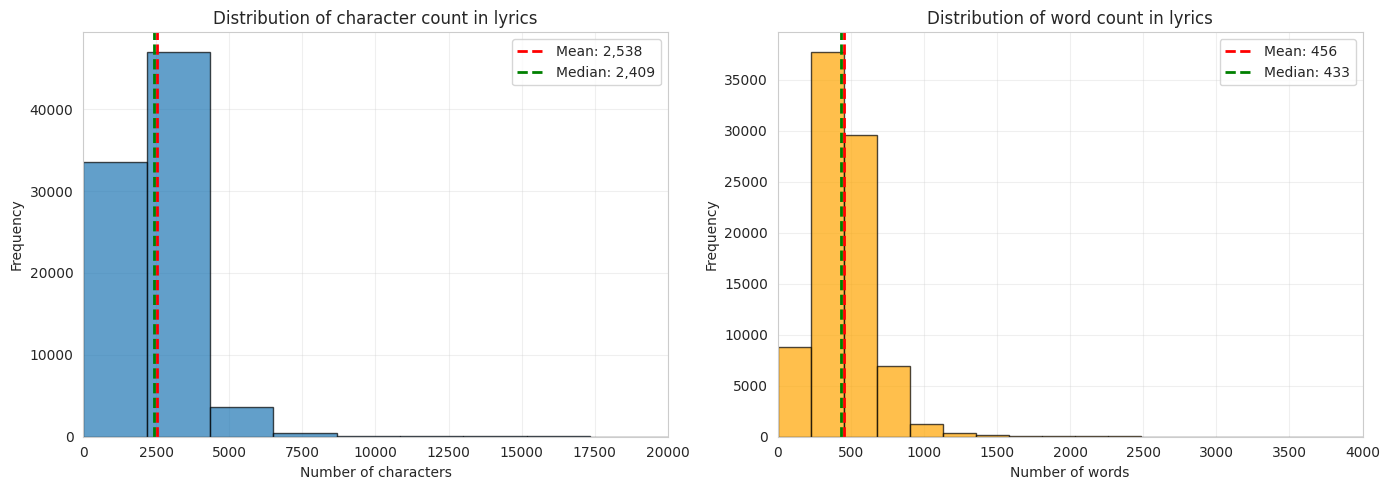

In [8]:
# Calculate length statistics for the lyrics column
df['char_count'] = df[text_col].fillna('').astype(str).str.len()
df['word_count'] = df[text_col].fillna('').astype(str).str.split().str.len()

# Global statistics
print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS - LYRICS ANALYSIS")
print("=" * 60)

print(f"\nCharacters per document:")
print(f"  Minimum: {df['char_count'].min():,} characters")
print(f"  Maximum: {df['char_count'].max():,} characters")
print(f"  Mean: {df['char_count'].mean():,.0f} characters")
print(f"  Median: {df['char_count'].median():,.0f} characters")
print(f"  Std Dev: {df['char_count'].std():,.0f}")

print(f"\nWords per document:")
print(f"  Minimum: {df['word_count'].min():,} words")
print(f"  Maximum: {df['word_count'].max():,} words")
print(f"  Mean: {df['word_count'].mean():,.0f} words")
print(f"  Median: {df['word_count'].median():,.0f} words")
print(f"  Std Dev: {df['word_count'].std():,.0f}")

# Calculate mean values
mean_chars = df['char_count'].mean()
median_chars = df['char_count'].median()
mean_words = df['word_count'].mean()
median_words = df['word_count'].median()

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character distribution
axes[0].hist(df['char_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(mean_chars, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_chars:,.0f}')
axes[0].axvline(median_chars, color='green', linestyle='--', linewidth=2, label=f'Median: {median_chars:,.0f}')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of character count in lyrics')
axes[0].set_xlim(0, 20000)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Word distribution
axes[1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(mean_words, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_words:,.0f}')
axes[1].axvline(median_words, color='green', linestyle='--', linewidth=2, label=f'Median: {median_words:,.0f}')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of word count in lyrics')
axes[1].set_xlim(0, 4000)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_dir / '01_text_length.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure saved: images/01_text_length.png")
plt.show()

## 4.1 Year-over-Year Evolution Analysis

Found potential year/date column: 'year'
Data type: Int64
Sample values: [2012, 2007, 2013, 2014, 2020, 2012, 2024, 2024, 2023, 2024]

--- Year Column Diagnostic ---
Total rows: 85,023
Rows with valid year values: 75,403
Rows with missing years: 9,620
Year range: 1 to 2025
Unique years found (41): [1, 12, 666, 1870, 1905, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

YEAR-OVER-YEAR STATISTICS (1990-2025)
Data points: 36 years
Documents analyzed: 75,387
 year  mean_chars  mean_words
 1990 3030.523810  557.476190
 1991 2680.882353  479.147059
 1992 3243.100000  562.700000
 1993 2986.019608  536.705882
 1994 2796.621622  508.810811
 1995 3104.575540  565.071942
 1996 2895.008929  532.080357
 1997 3272.867925  587.556604
 1998 3392.363636  608.482759
 1999 3546.537549  635.762846
 2000 3360.559184  604.677551
 2001 3356.0

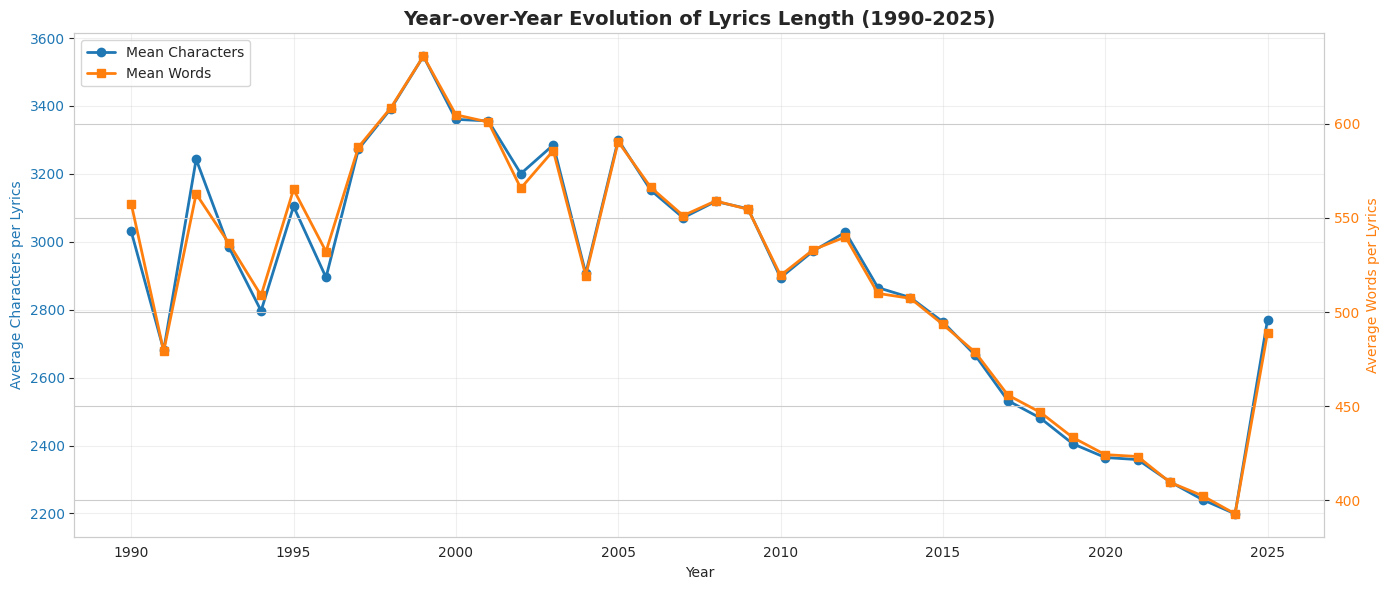

In [18]:
# Find date/year column
year_col = None
date_columns = [col for col in df.columns if any(term in col.lower() for term in ['year', 'date', 'time', 'release'])]

if date_columns:
    year_col = date_columns[0]
    print(f"Found potential year/date column: '{year_col}'")
    print(f"Data type: {df[year_col].dtype}")
    print(f"Sample values: {df[year_col].dropna().head(10).tolist()}")
    
    # Try to extract year
    try:
        # Convert to numeric first, handling floats like 2013.0 -> 2013
        # Remove NaN values and convert floats to integers
        df['year'] = pd.to_numeric(df[year_col], errors='coerce')
        # Convert floats to int (2013.0 becomes 2013, NaN stays NaN)
        df['year'] = df['year'].fillna(-1).astype(int)
        # Put NaN back for -1 values
        df.loc[df['year'] == -1, 'year'] = pd.NA
        df['year'] = df['year'].astype('Int64')
        
        # Show diagnostic info
        print(f"\n--- Year Column Diagnostic ---")
        print(f"Total rows: {len(df):,}")
        print(f"Rows with valid year values: {df['year'].notna().sum():,}")
        print(f"Rows with missing years: {df['year'].isna().sum():,}")
        
        year_min = df['year'].min()
        year_max = df['year'].max()
        print(f"Year range: {year_min} to {year_max}")
        
        # Show all unique years
        unique_years = sorted(df[df['year'].notna()]['year'].unique())
        print(f"Unique years found ({len(unique_years)}): {unique_years}")
        
        # Filter to 1990-2025 period and remove rows with missing years
        df_with_year = df[(df['year'].notna()) & (df['year'] >= 1990) & (df['year'] <= 2025)].copy()
        
        if len(df_with_year) > 0:
            # Make sure char_count and word_count exist
            if 'char_count' not in df_with_year.columns:
                df_with_year['char_count'] = df_with_year[text_col].fillna('').astype(str).str.len()
            if 'word_count' not in df_with_year.columns:
                df_with_year['word_count'] = df_with_year[text_col].fillna('').astype(str).str.split().str.len()
            
            # Group by year and calculate statistics
            yearly_stats = df_with_year.groupby('year').agg({
                'char_count': 'mean',
                'word_count': 'mean'
            }).reset_index()
            
            yearly_stats.columns = ['year', 'mean_chars', 'mean_words']
            yearly_stats = yearly_stats.sort_values('year')
            
            print("\n" + "=" * 60)
            print("YEAR-OVER-YEAR STATISTICS (1990-2025)")
            print("=" * 60)
            print(f"Data points: {len(yearly_stats)} years")
            print(f"Documents analyzed: {len(df_with_year):,}")
            print(yearly_stats.to_string(index=False))
            
            # Export yearly statistics
            yearly_stats.to_csv(export_dir / 'yearly_statistics.csv', index=False)
            print(f"\n✓ Yearly statistics exported: export/yearly_statistics.csv")
            
            # Create dual-axis plot
            fig, ax1 = plt.subplots(figsize=(14, 6))
            
            # Plot characters on left axis
            color1 = 'tab:blue'
            ax1.set_xlabel('Year')
            ax1.set_ylabel('Average Characters per Lyrics', color=color1)
            line1 = ax1.plot(yearly_stats['year'], yearly_stats['mean_chars'], 
                            color=color1, marker='o', linewidth=2, markersize=6, label='Mean Characters')
            ax1.tick_params(axis='y', labelcolor=color1)
            ax1.grid(True, alpha=0.3)
            
            # Create right axis for words
            ax2 = ax1.twinx()
            color2 = 'tab:orange'
            ax2.set_ylabel('Average Words per Lyrics', color=color2)
            line2 = ax2.plot(yearly_stats['year'], yearly_stats['mean_words'], 
                            color=color2, marker='s', linewidth=2, markersize=6, label='Mean Words')
            ax2.tick_params(axis='y', labelcolor=color2)
            
            # Title and legend
            plt.title('Year-over-Year Evolution of Lyrics Length (1990-2025)', fontsize=14, fontweight='bold')
            
            # Combine legends from both axes
            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            ax1.legend(lines, labels, loc='upper left', fontsize=10)
            
            fig.tight_layout()
            plt.savefig(images_dir / '01b_yearly_evolution.png', dpi=300, bbox_inches='tight')
            print("\n✓ Figure saved: images/01b_yearly_evolution.png")
            plt.show()
        else:
            print("\n⚠ No valid years found in the 1990-2025 period")
            print("The data may contain years outside this range.")
    except Exception as e:
        print(f"Error processing year column: {e}")
        import traceback
        traceback.print_exc()
else:
    print("No year/date column found in the dataset")
    print(f"Available columns: {df.columns.tolist()}")

## 5. Word Frequency Analysis


Total unique words: 379,546

Top 30 most frequent words:
  comme: 278,046
  mme: 107,415
  vie: 106,831
  rien: 82,879
  yeah: 73,182
  ya: 68,251
  temps: 55,583
  tte: 52,403
  o: 48,862
  gros: 43,086
  deux: 42,492
  monde: 40,922
  hey: 38,597
  cur: 37,725
  vu: 36,927
  juste: 36,688
  rap: 34,283
  fois: 34,118
  seul: 32,444
  mort: 32,172
  tre: 31,988
  quil: 31,829
  jen: 30,818
  jour: 28,899
  personne: 28,815
  parle: 28,613
  pourquoi: 28,223
  dj: 28,061
  vrai: 27,372
  nan: 27,209

✓ Top 200 words exported: export/top_words.csv
✓ Figure saved: images/02_word_frequency.png


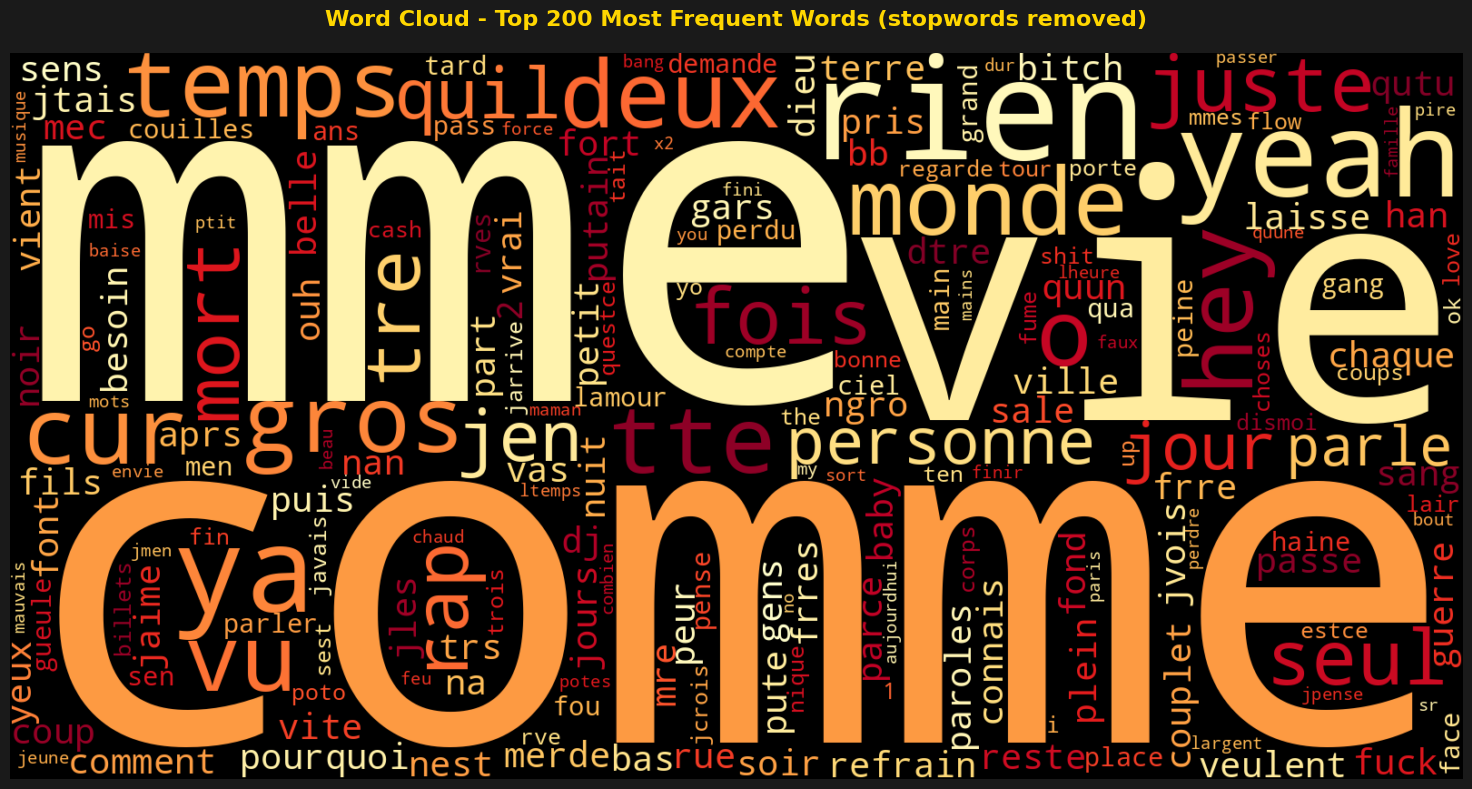

In [9]:
# Define French stopwords - comprehensive list
french_stopwords = {
    # Articles
    'le', 'la', 'les', 'un', 'une', 'des', 'du', 'l', 'au', 'aux', 'da', 'la', 'le',
    # Prépositions
    'à', 'de', 'en', 'par', 'pour', 'sur', 'avec', 'sans', 'sous', 'entre', 'dans',
    'vers', 'pendant', 'jusqu', 'depuis', 'après', 'avant', 'chez', 'selon', 'dès',
    'hors', 'malgré', 'lors', 'contre', 'parmi', 'devant', 'derrière', 'près', 'loin',
    'sauf', 'hormis', 'outre', 'vers', 'nonobstant', 'mors', 'afin', 'environs',
    # Pronoms personnels
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'on',
    'me', 'te', 'se', 'moi', 'toi', 'lui', 'eux', 'y', 'en',
    # Pronoms relatifs et démonstratifs
    'qui', 'que', 'quoi', 'dont', 'où', 'ce', 'cet', 'cette', 'ces',
    'celui', 'celle', 'ceux', 'celles', 'ça', 'ca', 'lequel', 'laquelle', 'lesquels', 'lesquelles',
    'ci', 'là', 'ceci', 'cela',
    # Conjonctions
    'et', 'ou', 'mais', 'donc', 'car', 'ni', 'soit', 'or', 'alors', 'lorsque',
    'quand', 'tandis', 'puisque', 'cependant', 'toutefois', 'néanmoins', 'sinon',
    'pourtant', 'bien', 'quoique', 'afin', 'pourvu',
    # Verbes auxiliaires et courants
    'est', 'sont', 'être', 'avoir', 'a', 'ai', 'as', 'avons', 'avez', 'ont',
    'était', 'étaient', 'étais', 'avait', 'avaient', 'sera', 'serait', 'seraient',
    'aura', 'auraient', 'suis', 'es', 'étant', 'ayant', 'ait', 'aient', 'aies',
    # Verbes très courants (faire, dire, prendre, mettre, venir, etc.)
    'faire', 'fais', 'fait', 'faisons', 'faites', 'faisait', 'ferai', 'ferais',
    'dire', 'dis', 'dit', 'disons', 'dites', 'disait', 'dirai', 'dirais',
    'prendre', 'prends', 'prend', 'prenons', 'prenez', 'prenait', 'prendrai',
    'mettre', 'mets', 'met', 'mettons', 'mettez', 'mettait', 'mettrai',
    'venir', 'viens', 'venons', 'veniez', 'venait', 'viendra',
    'aller', 'va', 'vais', 'vont', 'allons', 'allez', 'allait',
    'pouvoir', 'peux', 'peut', 'pouvons', 'pouvez', 'pouvait', 'pourrai',
    'vouloir', 'veux', 'veut', 'voulons', 'voulez', 'voulait', 'voudrai',
    'devoir', 'dois', 'doit', 'devons', 'devez', 'devait', 'devrai',
    'falloir', 'faut', 'fallait', 'faudra',
    'voir', 'vois', 'voit', 'voyons', 'voyez', 'voyait', 'verrai',
    'savoir', 'sais', 'sait', 'savons', 'saviez', 'savait', 'saurai',
    'croire', 'crois', 'croit', 'croyons', 'croyez', 'croyait',
    'vivre', 'vis', 'vit', 'vivons', 'viviez', 'vivait',
    'donner', 'donne', 'donnez', 'donnait', 'donnerai',
    'aller', 'aller', 'viens',
    # Adverbes courants
    'pas', 'ne', 'non', 'oui', 'très', 'plus', 'moins', 'bien', 'mal',
    'jamais', 'toujours', 'souvent', 'rarement', 'ici', 'là', 'maintenant', 'alors',
    'aujourd', 'hier', 'demain', 'encore', 'déjà', 'presque', 'seulement', 'aussi',
    'tant', 'assez', 'guère', 'aucun', 'quelque', 'tout', 'autres', 'autre',
    'trop', 'peu', 'beaucoup', 'tellement', 'vraiment', 'au moins', 'plutôt',
    'bientôt', 'longtemps', 'jamais', 'toujours', 'récemment', 'enfin', 'soudain',
    'particulièrement', 'notamment', 'généralement', 'absolument', 'certainement', 'peut',
    'probablement', 'certainement', 'évidemment', 'justement', 'clairement', 'doucement',
    'fortement', 'directement', 'indirectement', 'rapidement', 'lentement', 'facilement',
    'difficilement', 'naturellement', 'finalement', 'heureusement', 'malheureusement', 'loin',
    'proche', 'environ', 'partout', 'nulle', 'quelque', 'bien', 'mal', 'mieux',
    # Déterminants et articles contractés
    'mon', 'ton', 'son', 'notre', 'votre', 'leur', 'ma', 'ta', 'sa', 'mes', 'tes', 'ses', 'nos', 'vos', 'leurs',
    'quel', 'quelle', 'quels', 'quelles', 'quelques', 'plusieurs', 'beaucoup', 'peu',
    'ce', 'ces', 'cet', 'cette', 'aucun', 'nul', 'aucune', 'nulle', 'certain', 'certains',
    'certaine', 'certaines', 'tout', 'tous', 'toute', 'toutes', 'même', 'mêmes',
    # Particules et petits mots courants
    'c', 'd', 'l', 'n', 't', 's', 'q', 'j', 'z', 'r',
    'qu', 'ca', 'ça', 'là', 'ci', 'pas', 'si', 'ne', 'y', 'en',
    # Exclamations et interjections
    'oh', 'ah', 'eh', 'bah', 'ouf', 'pfut', 'chut', 'hein', 'hum', 'ouais',
    'ouah', 'ouille', 'aïe', 'bon', 'allé', 'bon', 'allez', 'dites', 'dis',
    # Contractions du langage parlé (sans apostrophes) - EXPANDED
    'jai', 'jas', 'jais', 'cest', 'cesque', 'quon', 'quils', 'quelles',
    'jveux', 'jveut', 'jpeux', 'jpeut', 'jfais', 'jfait', 'jsais', 'jsait',
    'jsuis', 'jme', 'jte', 'jti', 'jlui', 'jnous', 'jvous', 'jvais', 'jy',
    'tas', 'tatou', 'tas', 'telqu', 'tetait', 'tais', 'tétais',
    'dun', 'dune', 'dla', 'dquoi', 'dça',
    'ctait', 'cest', 'cque', 'cta', 'cétait', 'cea', 'ceque',
    'ym', 'yn', 'yavait', 'yfait', 'yva',
    'moij', 'moi', 'dja', 'djà', 'tjours', 'tjs', 'tjs',
    'jamis', 'naimais', 'naime', 'naimes', 'nsais', 'nsait',
    'ntais', 'ntai', 'ncest', 'ncesait', 'nceque', 'ncequ',
    'npeux', 'npeut', 'npas', 'nva', 'nvais', 'nvont', 'ny',
    'mfaut', 'mfait', 'mgros', 'mmanque', 'mplait',
    'mouais', 'mouai', 'nvé', 'nvais', 'ckoi', 'cetais',
    'yété', 'yaeu', 'yapas', 'yabien', 'yanul', 'yaeu',
    'pquoi', 'pqu', 'pquoi', 'pce', 'pceque', 'pcequ',
}

# Simple tokenizer and word counter
all_words = []
for text in df[text_col].fillna('').astype(str):
    # Convert to lowercase and split by spaces
    words = text.lower().split()
    # Clean punctuation and filter stopwords
    cleaned_words = [
        re.sub(r'[^a-z0-9]', '', word)
        for word in words
        if word.strip()
    ]
    all_words.extend([w for w in cleaned_words if w and w not in french_stopwords])

# Count frequencies
word_freq = Counter(all_words)
top_n = 30

print(f"\nTotal unique words: {len(word_freq):,}")
print(f"\nTop {top_n} most frequent words:")
for word, freq in word_freq.most_common(top_n):
    print(f"  {word}: {freq:,}")

# Save top words to CSV
top_words_df = pd.DataFrame(
    [(word, freq) for word, freq in word_freq.most_common(200)],
    columns=['word', 'frequency']
)
top_words_df.to_csv(export_dir / 'top_words.csv', index=False)
print(f"\n✓ Top 200 words exported: export/top_words.csv")

# Generate Word Cloud with top 200 words and aggressive logarithmic scaling
top_200_words = dict(word_freq.most_common(200))

# Apply aggressive logarithmic scaling for better word distribution
# Using log(log(freq)) compresses large frequencies more effectively
log_freq = {word: np.log1p(np.log1p(freq)) for word, freq in top_200_words.items()}

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    colormap='YlOrRd',  # Hip hop aesthetic: gold/orange/red
    max_words=200,
    relative_scaling=0.3,  # Reduced from 0.7 for better balance
    min_font_size=10,
    prefer_horizontal=0.7
).generate_from_frequencies(log_freq)

fig, ax = plt.subplots(figsize=(16, 8), facecolor='#1a1a1a')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud - Top 200 Most Frequent Words (stopwords removed)', fontsize=16, fontweight='bold', pad=20, color='#FFD700')
plt.tight_layout()
plt.savefig(images_dir / '02_word_frequency.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
print("✓ Figure saved: images/02_word_frequency.png")
plt.show()

## 5b. Word Clouds by Era (Before 2000, 2000-2015, After 2015)

WORD CLOUDS BY ERA

--- BEFORE 2000 (1990-1999) ---
Documents: 1,188
Total words: 337,768
Unique words: 44,441
Top 10 words: comme, vie, mme, rien, o, temps, monde, couplet, quil, rap

--- 2000 - 2015 (2000-2015) ---
Documents: 18,092
Total words: 4,684,863
Unique words: 190,644
Top 10 words: comme, mme, vie, rien, ya, o, rap, temps, monde, tte

--- AFTER 2015 (2016-2025) ---
Documents: 56,107
Total words: 11,516,888
Unique words: 272,068
Top 10 words: comme, mme, vie, yeah, rien, ya, temps, tte, hey, deux

✓ Figure saved: images/02b_word_clouds_by_era.png


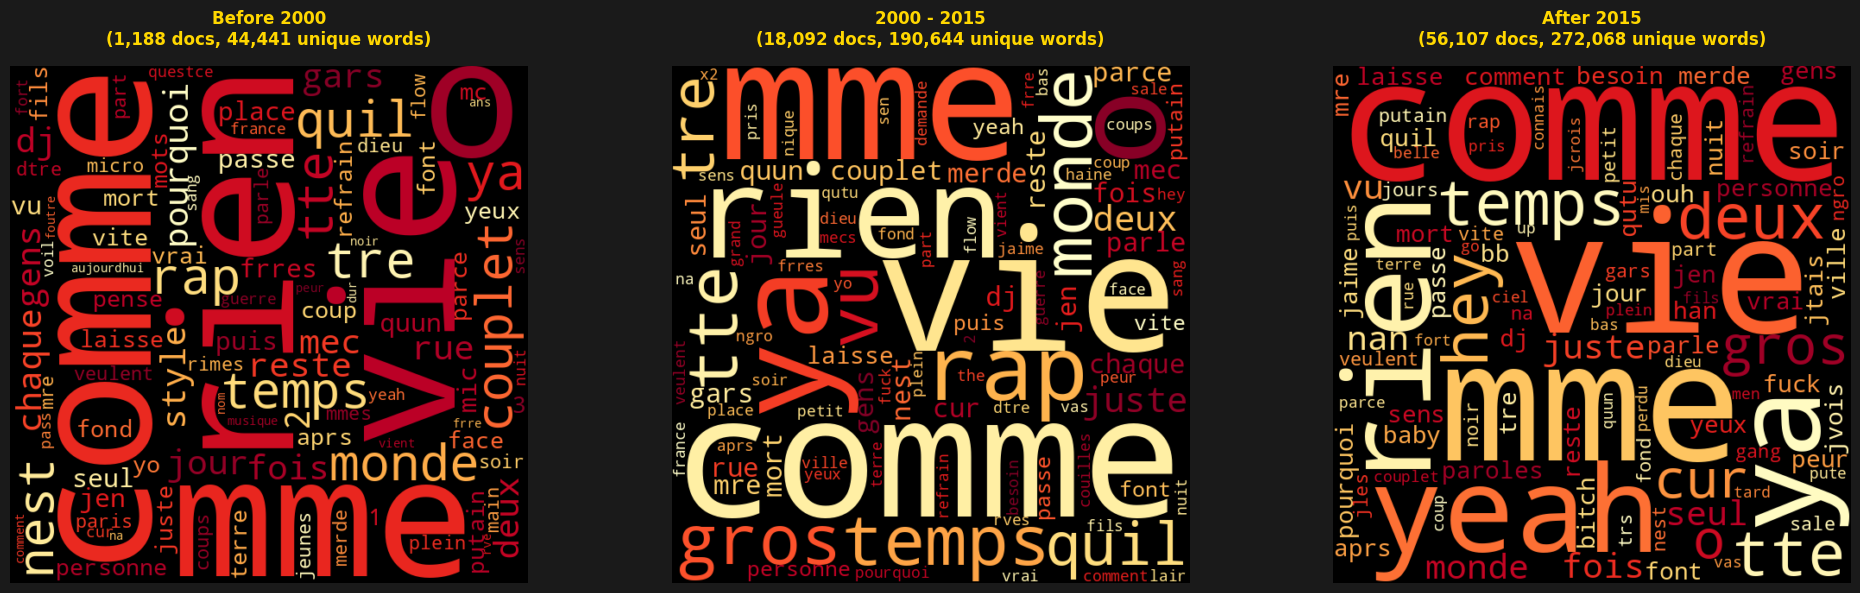


EXPORT SUMMARY BY ERA
✓ Exported top_words_before_2000.csv: 50 top words from Before 2000
✓ Exported top_words_2000_2015.csv: 50 top words from 2000 - 2015
✓ Exported top_words_after_2015.csv: 50 top words from After 2015


In [10]:
# Generate 3 word clouds by era: before 2000, 2000-2015, after 2015
print("=" * 80)
print("WORD CLOUDS BY ERA")
print("=" * 80)

# Define periods
periods = [
    ('before_2000', 1990, 1999, 'Before 2000'),
    ('2000_2015', 2000, 2015, '2000 - 2015'),
    ('after_2015', 2016, 2025, 'After 2015')
]

# Make sure year column exists
if 'year' not in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['year'] = df['year'].fillna(-1).astype(int)
    df.loc[df['year'] == -1, 'year'] = pd.NA
    df['year'] = df['year'].astype('Int64')

# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#1a1a1a')

word_clouds_data = {}

for idx, (period_id, year_start, year_end, period_name) in enumerate(periods):
    print(f"\n--- {period_name.upper()} ({year_start}-{year_end}) ---")
    
    # Filter data by period
    df_period = df[(df['year'].notna()) & (df['year'] >= year_start) & (df['year'] <= year_end)]
    
    if len(df_period) > 0:
        # Extract and count words for this period
        period_words = []
        for text in df_period[text_col].fillna('').astype(str):
            words = text.lower().split()
            cleaned_words = [re.sub(r'[^a-z0-9]', '', word) for word in words if word.strip()]
            period_words.extend([w for w in cleaned_words if w and w not in french_stopwords])
        
        period_freq = Counter(period_words)
        top_100_words = dict(period_freq.most_common(100))
        
        print(f"Documents: {len(df_period):,}")
        print(f"Total words: {len(period_words):,}")
        print(f"Unique words: {len(period_freq):,}")
        print(f"Top 10 words: {', '.join([w for w, _ in period_freq.most_common(10)])}")
        
        # Apply aggressive logarithmic scaling
        log_freq_period = {word: np.log1p(np.log1p(freq)) for word, freq in top_100_words.items()}
        
        # Generate word cloud
        wordcloud = WordCloud(
            width=600,
            height=600,
            background_color='black',
            colormap='YlOrRd',
            max_words=100,
            relative_scaling=0.3,
            min_font_size=8,
            prefer_horizontal=0.7
        ).generate_from_frequencies(log_freq_period)
        
        # Display on subplot
        ax = axes[idx]
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{period_name}\n({len(df_period):,} docs, {len(period_freq):,} unique words)',
                    fontsize=12, fontweight='bold', color='#FFD700', pad=15)
        
        # Store data for export
        word_clouds_data[period_id] = {
            'period': period_name,
            'doc_count': len(df_period),
            'unique_words': len(period_freq),
            'top_words': period_freq.most_common(50)
        }
    else:
        ax = axes[idx]
        ax.text(0.5, 0.5, f'No data for {period_name}', ha='center', va='center',
               color='#FFD700', fontsize=14, transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()
plt.savefig(images_dir / '02b_word_clouds_by_era.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
print("\n✓ Figure saved: images/02b_word_clouds_by_era.png")
plt.show()

# Export statistics for each era
print("\n" + "=" * 80)
print("EXPORT SUMMARY BY ERA")
print("=" * 80)

for period_id, data in word_clouds_data.items():
    period_df = pd.DataFrame(
        [(word, freq) for word, freq in data['top_words']],
        columns=['word', 'frequency']
    )
    filename = f"top_words_{period_id}.csv"
    period_df.to_csv(export_dir / filename, index=False)
    print(f"✓ Exported {filename}: {len(data['top_words'])} top words from {data['period']}")


## 6. Vocabulary Size and Lexical Diversity

LEXICAL DIVERSITY AND VOCABULARY

Vocabulary:
  Total unique words: 379,546
  Total word tokens: 18,657,621
  Type/Token Ratio (TTR): 0.0203

------------------------------------------------------------
Diversity per Document:
  Mean TTR per document: 0.5075
  Min TTR: 0.0275
  Max TTR: 1.0000
  Median TTR: 0.4978

------------------------------------------------------------
Unique words (appear only once): 173,705
Percentage of vocabulary: 45.77%

------------------------------------------------------------
Word frequency distribution:
  Words appearing 1 time: 173,705
  Words appearing 2-5 times: 100,435
  Words appearing 6-10 times: 30,617
  Words appearing 11+ times: 74,789

✓ Diversity statistics exported: export/lexical_diversity_stats.csv
✓ Figure saved: images/03_lexical_diversity.png


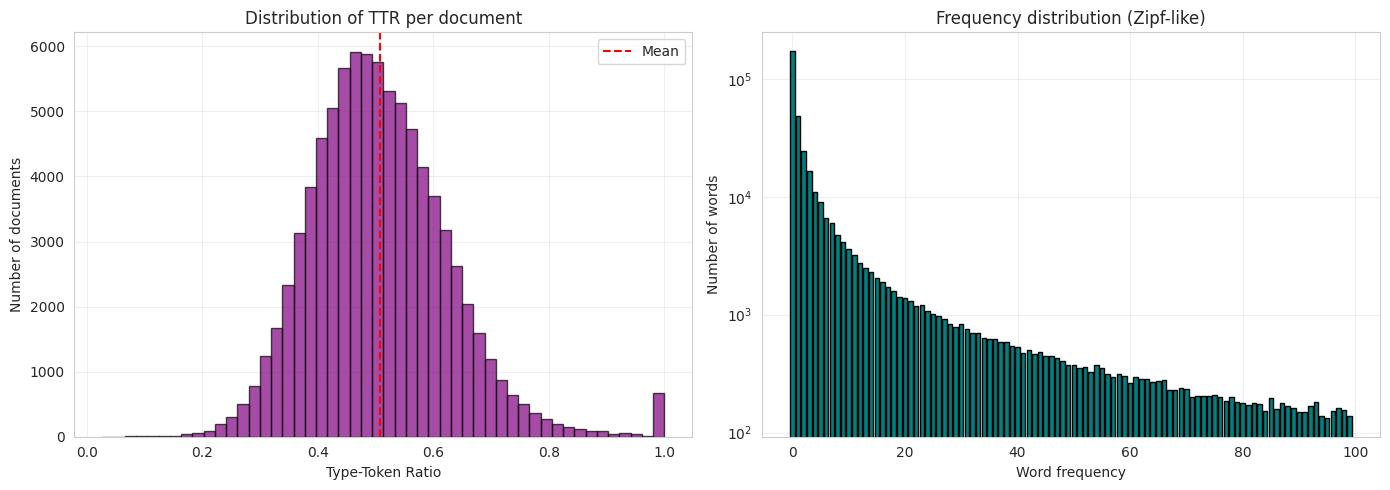

In [11]:
print("=" * 60)
print("LEXICAL DIVERSITY AND VOCABULARY")
print("=" * 60)

# Total vocabulary size
total_vocab = len(word_freq)
total_words = sum(word_freq.values())

print(f"\nVocabulary:")
print(f"  Total unique words: {total_vocab:,}")
print(f"  Total word tokens: {total_words:,}")
print(f"  Type/Token Ratio (TTR): {total_vocab / total_words:.4f}")

# Diversity per document
print(f"\n" + "-" * 60)
print("Diversity per Document:")

doc_diversity = []
for text in df[text_col].fillna('').astype(str):
    words_in_doc = text.lower().split()
    unique_in_doc = len(set(words_in_doc))
    if len(words_in_doc) > 0:
        ttr = unique_in_doc / len(words_in_doc)
        doc_diversity.append(ttr)

print(f"  Mean TTR per document: {np.mean(doc_diversity):.4f}")
print(f"  Min TTR: {np.min(doc_diversity):.4f}")
print(f"  Max TTR: {np.max(doc_diversity):.4f}")
print(f"  Median TTR: {np.median(doc_diversity):.4f}")

# Rare and frequent words
rare_words = {word: freq for word, freq in word_freq.items() if freq == 1}
print(f"\n" + "-" * 60)
print(f"Unique words (appear only once): {len(rare_words):,}")
print(f"Percentage of vocabulary: {len(rare_words) / total_vocab * 100:.2f}%")

# Frequency distribution
freq_distribution = Counter(word_freq.values())
print(f"\n" + "-" * 60)
print(f"Word frequency distribution:")
print(f"  Words appearing 1 time: {freq_distribution[1]:,}")
print(f"  Words appearing 2-5 times: {sum(c for f, c in freq_distribution.items() if 2 <= f <= 5):,}")
print(f"  Words appearing 6-10 times: {sum(c for f, c in freq_distribution.items() if 6 <= f <= 10):,}")
print(f"  Words appearing 11+ times: {sum(c for f, c in freq_distribution.items() if f >= 11):,}")

# Export diversity statistics
diversity_stats = pd.DataFrame({
    'metric': ['total_vocabulary', 'unique_words', 'global_ttr', 'mean_ttr_doc', 'ttr_min', 'ttr_max', 'ttr_median', 'rare_words', 'pct_rare_words'],
    'value': [total_vocab, total_words, total_vocab / total_words, np.mean(doc_diversity), np.min(doc_diversity), np.max(doc_diversity), np.median(doc_diversity), len(rare_words), len(rare_words) / total_vocab * 100]
})
diversity_stats.to_csv(export_dir / 'lexical_diversity_stats.csv', index=False)
print(f"\n✓ Diversity statistics exported: export/lexical_diversity_stats.csv")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TTR histogram per document
axes[0].hist(doc_diversity, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(np.mean(doc_diversity), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Type-Token Ratio')
axes[0].set_ylabel('Number of documents')
axes[0].set_title('Distribution of TTR per document')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Frequency distribution (log scale)
freq_counts = sorted(freq_distribution.items())
if len(freq_counts) > 0:
    freqs, counts = zip(*freq_counts[:min(100, len(freq_counts))])
    axes[1].bar(range(len(freqs)), counts, color='teal', edgecolor='black')
    axes[1].set_xlabel('Word frequency')
    axes[1].set_ylabel('Number of words')
    axes[1].set_title('Frequency distribution (Zipf-like)')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_dir / '03_lexical_diversity.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved: images/03_lexical_diversity.png")
plt.show()

## 7. Character-Level Statistics

CHARACTER-LEVEL STATISTICS

Character breakdown:
  Total: 215,822,908
  Letters: 165,169,435 (76.53%)
  Digits: 411,796 (0.19%)
  Spaces: 39,472,303 (18.29%)
  Punctuation: 9,993,977 (4.63%)
  Other: 775,397 (0.36%)

------------------------------------------------------------
Top 15 most frequent characters:
  ' ': 34,068,311
  e: 21,943,644
  s: 14,809,498
  a: 13,800,816
  i: 10,657,577
  t: 10,160,378
  u: 10,157,784
  n: 9,957,090
  r: 9,748,328
  o: 9,291,188
  l: 8,272,729
  m: 5,405,253
  '\n': 5,306,000
  d: 5,193,421
  c: 4,711,606

------------------------------------------------------------
Punctuation breakdown:
  '!': 73,671
  '"': 165,069
  '#': 3,399
  '$': 5,303
  '%': 1,445
  '&': 21,456
  ''': 4,603,860
  '(': 382,966
  ')': 383,017
  '*': 15,650
  '+': 1,151
  ',': 3,105,253
  '-': 593,695
  '.': 209,925
  '/': 10,968
  ':': 99,233
  ';': 6,322
  '<': 70
  '=': 161
  '>': 88
  '?': 170,452
  '@': 79
  '[': 69,128
  '\': 11
  ']': 69,147
  '^': 33
  '_': 978
  '`': 8

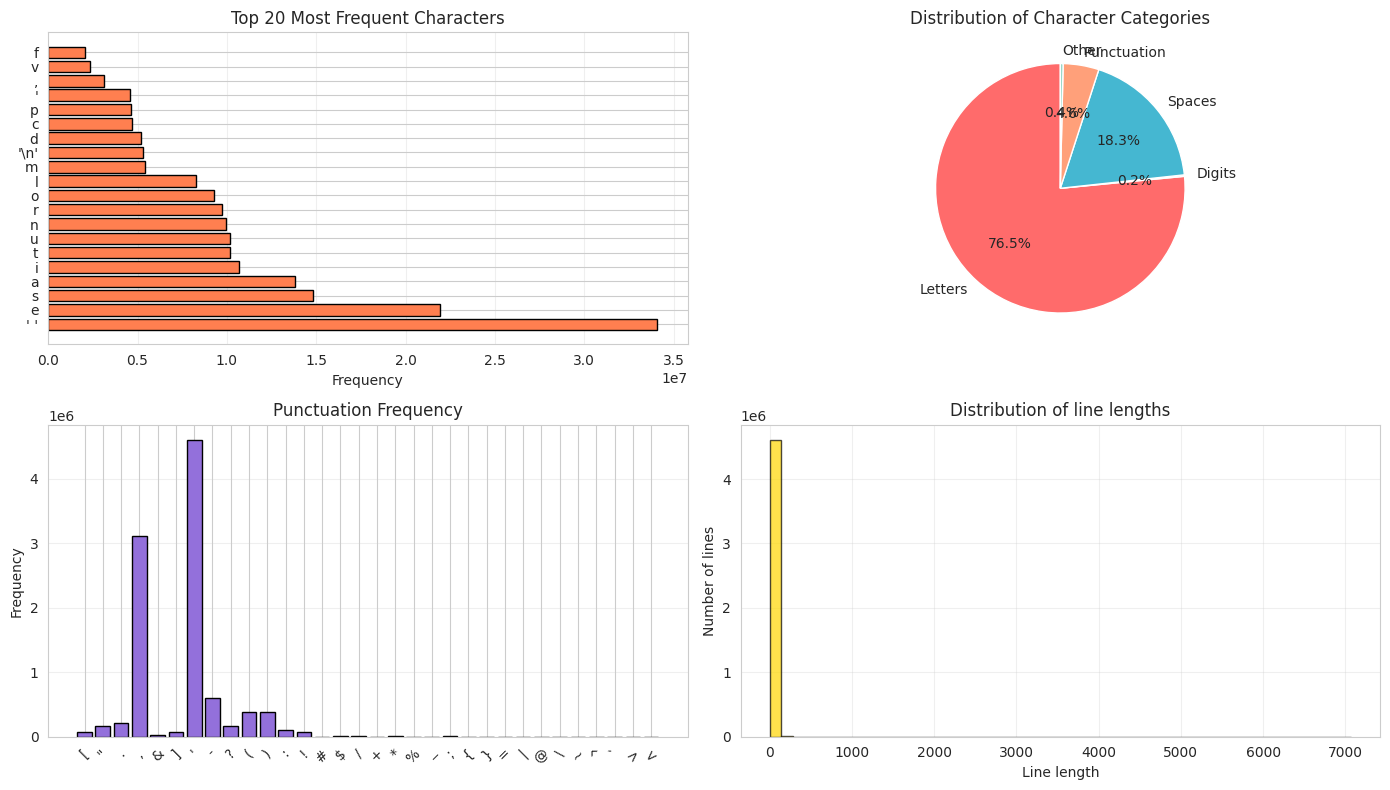


ANALYSIS COMPLETED

✓ Results saved in:
  - images/: 6 PNG figures
  - export/: CSV files with detailed statistics


In [12]:
print("=" * 60)
print("CHARACTER-LEVEL STATISTICS")
print("=" * 60)

# Count all types of characters
all_chars = ''.join(df[text_col].fillna('').astype(str))
char_freq = Counter(all_chars)

# Categorize characters
punctuation_chars = sum(count for char, count in char_freq.items() if char in string.punctuation)
digit_chars = sum(count for char, count in char_freq.items() if char.isdigit())
letter_chars = sum(count for char, count in char_freq.items() if char.isalpha())
space_chars = sum(count for char, count in char_freq.items() if char.isspace())
other_chars = len(all_chars) - punctuation_chars - digit_chars - letter_chars - space_chars

total_chars = len(all_chars)

print(f"\nCharacter breakdown:")
print(f"  Total: {total_chars:,}")
print(f"  Letters: {letter_chars:,} ({letter_chars/total_chars*100:.2f}%)")
print(f"  Digits: {digit_chars:,} ({digit_chars/total_chars*100:.2f}%)")
print(f"  Spaces: {space_chars:,} ({space_chars/total_chars*100:.2f}%)")
print(f"  Punctuation: {punctuation_chars:,} ({punctuation_chars/total_chars*100:.2f}%)")
print(f"  Other: {other_chars:,} ({other_chars/total_chars*100:.2f}%)")

# Top most frequent characters
print(f"\n" + "-" * 60)
print(f"Top 15 most frequent characters:")
for char, freq in char_freq.most_common(15):
    char_display = repr(char) if char.isspace() or char in string.punctuation else char
    print(f"  {char_display}: {freq:,}")

# Detailed punctuation
print(f"\n" + "-" * 60)
print(f"Punctuation breakdown:")
punct_freq = {char: count for char, count in char_freq.items() if char in string.punctuation}
for char in sorted(punct_freq.keys()):
    count = punct_freq[char]
    print(f"  '{char}': {count:,}")

# Export character statistics
char_stats = pd.DataFrame({
    'category': ['letters', 'digits', 'spaces', 'punctuation', 'other', 'total'],
    'count': [letter_chars, digit_chars, space_chars, punctuation_chars, other_chars, total_chars],
    'percentage': [
        letter_chars/total_chars*100,
        digit_chars/total_chars*100,
        space_chars/total_chars*100,
        punctuation_chars/total_chars*100,
        other_chars/total_chars*100,
        100.0
    ]
})
char_stats.to_csv(export_dir / 'character_statistics.csv', index=False)
print(f"\n✓ Character statistics exported: export/character_statistics.csv")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top 20 characters
top_chars = dict(char_freq.most_common(20))
chars_display = [repr(c) if c.isspace() else c for c in top_chars.keys()]
axes[0, 0].barh(chars_display, list(top_chars.values()), color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 20 Most Frequent Characters')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Character category distribution
categories = ['Letters', 'Digits', 'Spaces', 'Punctuation', 'Other']
counts = [letter_chars, digit_chars, space_chars, punctuation_chars, other_chars]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
axes[0, 1].pie(counts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Distribution of Character Categories')

# Punctuation frequency
if punct_freq:
    punct_chars = list(punct_freq.keys())
    punct_counts = list(punct_freq.values())
    axes[1, 0].bar(punct_chars, punct_counts, color='mediumpurple', edgecolor='black')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Punctuation Frequency')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# Line length distribution
line_lengths = [len(line) for line in str(all_chars).split('\n') if line.strip()]
if line_lengths:
    axes[1, 1].hist(line_lengths, bins=50, edgecolor='black', alpha=0.7, color='gold')
    axes[1, 1].set_xlabel('Line length')
    axes[1, 1].set_ylabel('Number of lines')
    axes[1, 1].set_title('Distribution of line lengths')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')

plt.tight_layout()
plt.savefig(images_dir / '04_character_statistics.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved: images/04_character_statistics.png")
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETED")
print("=" * 60)
print(f"\n✓ Results saved in:")
print(f"  - images/: {len(list(images_dir.glob('*.png')))} PNG figures")
print(f"  - export/: CSV files with detailed statistics")

## Summary and Export of Global Statistics

In [ ]:
# Create a summary report
summary_report = f"""
================================================================================
EXPLORATORY ANALYSIS REPORT - RAP CORPUS
================================================================================

Analysis date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. CORPUS METADATA
-------------------
   - Number of documents: {len(df):,}
   - Number of columns: {df.shape[1]}
   - Analyzed column: {text_col}
   - Memory size: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB

2. LENGTH STATISTICS
---------------------
   Characters per document:
   - Min: {df['char_count'].min():,}
   - Max: {df['char_count'].max():,}
   - Mean: {df['char_count'].mean():,.0f}
   - Median: {df['char_count'].median():,.0f}
   - Std Dev: {df['char_count'].std():,.0f}

   Words per document:
   - Min: {df['word_count'].min():,}
   - Max: {df['word_count'].max():,}
   - Mean: {df['word_count'].mean():,.0f}
   - Median: {df['word_count'].median():,.0f}
   - Std Dev: {df['word_count'].std():,.0f}

3. VOCABULARY AND DIVERSITY
-----------------------------
   - Total vocabulary: {len(word_freq):,} unique words
   - Total tokens: {sum(word_freq.values()):,}
   - Type/Token Ratio (TTR): {len(word_freq) / sum(word_freq.values()):.4f}
   - Mean TTR per document: {np.mean(doc_diversity):.4f}
   - Words appearing only once: {len(rare_words):,} ({len(rare_words) / len(word_freq) * 100:.2f}%)

4. CHARACTER ANALYSIS
----------------------
   - Total characters: {total_chars:,}
   - Letters: {letter_chars:,} ({letter_chars/total_chars*100:.2f}%)
   - Digits: {digit_chars:,} ({digit_chars/total_chars*100:.2f}%)
   - Spaces: {space_chars:,} ({space_chars/total_chars*100:.2f}%)
   - Punctuation: {punctuation_chars:,} ({punctuation_chars/total_chars*100:.2f}%)
   - Other: {other_chars:,} ({other_chars/total_chars*100:.2f}%)

5. TOP MOST FREQUENT WORDS (Top 10)
-------------------------------------
"""

for i, (word, freq) in enumerate(word_freq.most_common(10), 1):
    summary_report += f"   {i:2d}. {word:20s} - {freq:,} occurrences\n"

summary_report += f"""
================================================================================
GENERATED FILES
================================================================================

Images (PNG):
   - 01_text_length.png              : Distribution of text lengths
   - 02_word_frequency.png           : Top 30 most frequent words
   - 03_lexical_diversity.png        : Diversity statistics
   - 04_character_statistics.png     : Character analysis

Data (CSV):
   - top_words.csv                   : Top 100 words with frequencies
   - lexical_diversity_stats.csv     : Lexical diversity metrics
   - character_statistics.csv        : Character distribution
   - summary_report.txt              : This report

================================================================================
END OF REPORT
================================================================================
"""

# Save the report
with open(export_dir / 'summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(summary_report)
print(f"\n✓ Summary report saved: export/summary_report.txt")